<a href="https://colab.research.google.com/github/hannahbakergomez-dotcom/Fintrackfinalproject/blob/main/Midterm_modelling_%26_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final computed probability of drawing a Flush = 0.4 %


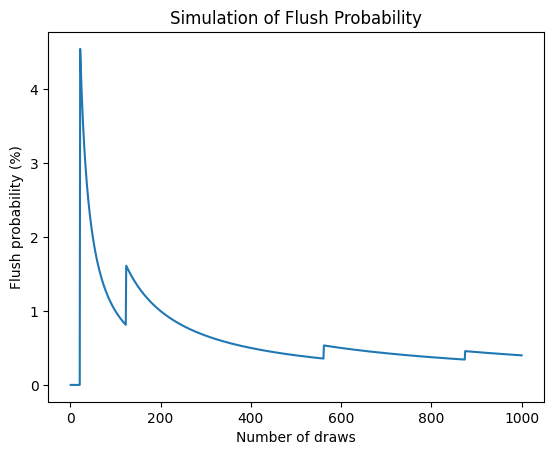

In [ ]:
#Question 2
import random
import matplotlib.pyplot as plt

iterations = 1000 #@param {type:"slider", min:1000, max:50000, step:100}

class PlayingCard:
    SUITS = ["♦", "♣", "♥", "♠"]
    RANKS = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]

    def __init__(self, suit, rank):
        if suit not in self.SUITS:
            raise ValueError
        if rank not in self.RANKS:
            raise ValueError

        self._suit = suit
        self._rank = rank

    @property
    def suit(self):
        return self._suit

    @property
    def rank(self):
        return self._rank

    def __str__(self):
        return f"{self.rank}{self.suit}"

    def __repr__(self):
        return self.__str__()


class Deck:
    def __init__(self):
        self._cards = []

        for suit in PlayingCard.SUITS:
            for rank in PlayingCard.RANKS:
                self._cards.append(PlayingCard(suit, rank))

    def shuffle(self):
        random.shuffle(self._cards)

    def deal(self):
        return self._cards.pop(8)


class PokerHand:
    def __init__(self):
        deck = Deck()
        deck.shuffle()

        self._cards = []

        for _ in range(5):
            self._cards.append(deck.deal())

    @property
    def num_matches(self):
        count = 0
        for i in range(5):
            for j in range(5):
                if i == j:
                    continue
                if self._cards[i].rank == self._cards[j].rank:
                    count += 1
        return count

    @property
    def is_straight(self):
        if self.num_matches != 0:
            return False

        cards = list(self._cards)
        cards.sort(key=lambda card: PlayingCard.RANKS.index(card.rank))

        first_card_index = PlayingCard.RANKS.index(cards[0].rank)
        last_card_index = PlayingCard.RANKS.index(cards[-1].rank)

        if first_card_index + 4 == last_card_index:
            return True

        if cards[-1].rank == "A" and cards[-2].rank == "5":
            return True

        return False

    @property
    def is_flush(self):
        for card in self._cards[1:]:
            if self._cards[0].suit != card.suit:
                return False

        if self.is_straight:
            return False

        return True


flushes = 0
draws = []
probabilities = []

for draw in range(1, iterations + 1):

    hand = PokerHand()

    if hand.is_flush:
        flushes = flushes + 1

    probability = flushes / draw * 100

    draws.append(draw)
    probabilities.append(probability)


print("Final computed probability of drawing a Flush =", probability,"%")

plt.plot(draws, probabilities)
plt.xlabel("Number of draws")
plt.ylabel("Flush probability (%)")
plt.title("Simulation of Flush Probability")
plt.show()

[*********************100%***********************]  1 of 1 completed


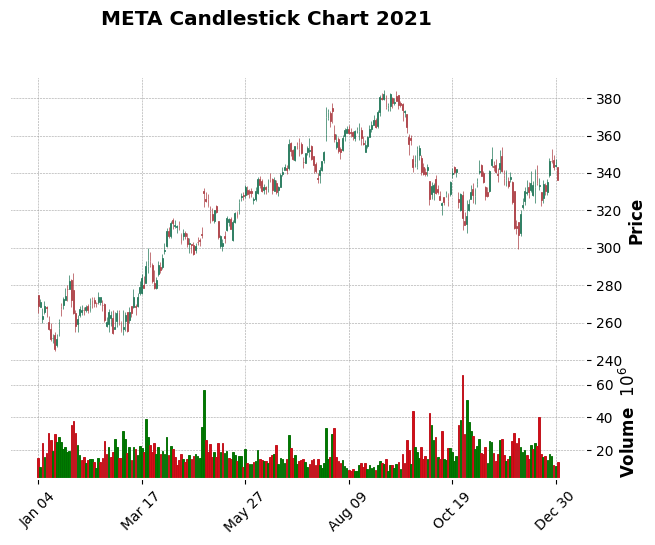

Best day for Meta:
2021-06-28 3.8486315254984325 %

Worst day for Meta:
2021-12-01 -5.961428421086575 %


In [ ]:
!pip install yfinance mplfinance

import yfinance as yf
import pandas as pd
import mplfinance as mpf

ticker = "META"

data = yf.download(ticker,
                   start="2021-01-01",
                   end="2022-01-01",
                   auto_adjust=False)

# Fix in case yfinance downloads multi-level columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Keep only columns needed for candlestick chart
data = data[["Open", "High", "Low", "Close", "Volume"]]

mpf.plot(data,
         type="candle",
         style="charles",
         volume=True,
         title="META Candlestick Chart 2021")

data["Daily_pct_change"] = ((data["Close"] - data["Open"]) / data["Open"]) * 100

best_day = data["Daily_pct_change"].idxmax()
best_gain = data["Daily_pct_change"].max()

worst_day = data["Daily_pct_change"].idxmin()
worst_loss = data["Daily_pct_change"].min()

print("Best day for Meta:")
print(best_day.date(), best_gain, "%")

print("\nWorst day for Meta:")
print(worst_day.date(), worst_loss, "%")

In [ ]:
# Question 4

import numpy as np
import pandas as pd

df = pd.DataFrame(np.random.randn(4,4),
                  index=[1,2,3,4],
                  columns=['a','b','c','d'])

print(df)

# choose row 2, column b

print("\nUsing index:")
print(df["b"][2])

print("\nUsing loc:")
print(df.loc[2,"b"])

print("\nUsing iloc:")
print(df.iloc[1,1])

          a         b         c         d
1 -0.484141  0.160418  0.551315  0.444480
2  1.565678 -0.794840 -0.202815  0.563548
3 -0.136051  0.605429  0.330177  1.425051
4 -0.288105 -0.482278  0.926302  1.140065

Using index:
-0.794840197352265

Using loc:
-0.794840197352265

Using iloc:
-0.794840197352265


Minimum value of y = 2.0


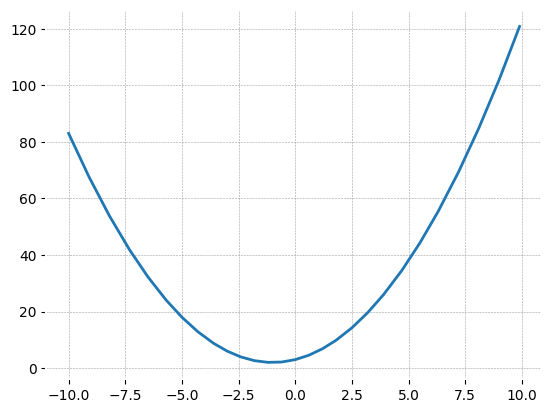

In [ ]:
#Question 6
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-10,10,0.1)
y = x**2 + 2*x + 3

print("Minimum value of y =", min(y))

plt.plot(x,y)
plt.show()

In [ ]:
#Question 8

class Point:

    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"p<{self.x},{self.y}>"

    def __lt__(self,other):
        return self.x < other.x

    def distance_origin(self):
        return (self.x**2 + self.y**2)**0.5

In [ ]:
#Question 9

import numpy as np

a = np.arange(0,12)

a = a.reshape(6,2)
a = a**2 + 3

print(a)

[[  3   4]
 [  7  12]
 [ 19  28]
 [ 39  52]
 [ 67  84]
 [103 124]]
